In [1]:
import torch
import time
import numpy as np
from matplotlib import pyplot as plt
import random

### 3 线性神经网路
- 训练过程
  - 定义神经网络架构
  - 数据处理
  - 指定损失函数
  - 训练模型
- 线性回归
- softmax回归
#### 3.1 线性回归
- 回归（Regression）：能为一个或多个自变量与因变量之间的关系建模的一类方法，表示输入和输出的关系。
- **预测（Prediction）**
##### 3.1.1 线性回归的基本元素
- 线性回归（Linear Regression）
  - 自变量$\mathbf{x}$和因变量$\mathbf{y}$之间的关系是线性的
  - 噪声遵循类似正态分布
1. 线性模型

举例：$price=w_{area} \cdot area + w_{age} \cdot age + b$
- 目标：房价
- 特征：面积；房龄
- $w_{area}, w_{age}$：权重（Weight）
- $b$：偏置（Bias）/偏移量（Offset）/截距（Intercept）
- 任务：寻找模型的权重和偏置，使得根据模型做出的预测大体符合数据中的真实价格。

一般形式：
- 单个数据样本：$\mathbf{x}$的特征$\hat{y}=\mathbf{w}^T\mathbf{x}+b$
- 特征集合$\mathbf{X}$，每一行是一个样本，每一列是一个特征：$\hat{\mathbf{y}}=\mathbf{X}\mathbf{w}+b$

2. 损失函数
- 损失函数（Loss Function）：量化目标的实际值与预测值之间的差距。常采用非负数作为损失，数值越小表示损失越少。
- 平方误差：线性回归的损失函数采用平法误差函数，当样本$i$的预测值为$\hat{y}^{(i)}$，定义平方误差
$$l^{(i)}(\mathbf{w},b)=\frac{1}{2}(\hat{y}^{(i)}-y^{(i)})^2$$
- 度量模型在整个数据集上的预测质量，计算训练集n个样本上的损失均值：
$$L(\mathbf{w}, b)=\frac{1}{n}\sum ^n _{i=1}l^{(i)}(\mathbf{w},b)=\frac{1}{n}\sum ^n _{i=1}\frac{1}{2}(\hat{y}^{(i)}-y^{(i)})^2$$
- 任务：寻找一组$(\mathbf{w}^*, b^*)$，这组参数能最小化所有训练样本上的总损失
$$\mathbf{w}^*, b^* = \min_{\mathbf{w}, b} L(\mathbf{w}, b)$$

3. 解析解
- 解析解（Analytical Solution）：线性回归的解用公式表达。线性问题存在解析解。
- 预测问题：最小化$||\mathbf{y}-\mathbf{Xw}||^2$
- 将损失关于$\mathbf{w}$的导数设为0，得到$\mathbf{w}=(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$

4. 随机梯度下降
- 梯度下降（Gradient Descent）：通过不断地在损失函数递减的方向上更新参数来降低误差。
- 小批量随机梯度下降（Minibatch Stochastic Gradient Descent）：每次需要在计算更新的时候随机抽取一小批样本。
- 更新过程：
$$(\mathbf{w},b)\leftarrow (\mathbf{w},b)-\frac{\eta}{|B|}\sum_{i \in B}\partial _{(\mathbf{w},b)}l^{(i)}(\mathbf{w},b) $$

5. 用模型进行预测
- 预测（Prediction）/推断（Inference）给定特征的情况下估计目标的过程

##### 3.1.2 向量化加速
使用线性代数库，对计算进行向量化，而不是使用for循环。

In [6]:
n = 10000
a = torch.ones(n)
b = torch.ones(n)

class Timer:    #@save
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """启动计时器"""
        self.tik = time.time()

    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回时间总和"""
        return sum(self.times)

    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()

方法一：使用for循环。

In [7]:
c = torch.zeros(n)
timer = Timer()
for i in range(n):
    c[i] = a[i] + b[i]
f'{timer.stop():.5f} sec'

'0.10785 sec'

方法二：使用重载的+运算符计算元素的和。

In [8]:
timer.start()
d = a + b
f'{timer.stop():.5f} sec'

'0.00000 sec'

##### 3.1.3 正态分布与平方损失
假设观测中包含服从正态分布的误差：$y=\mathbf{w}^T\mathbf{x}+b+\epsilon, \epsilon\sim N(0,\sigma ^2)$

似然：$$P(y|\mathbf{x})=\frac{1}{\sqrt{2\pi\sigma ^2}}e^{-\frac{1}{2\sigma ^2}(y-\mathbf{w}^T\mathbf{x}-b)^2}$$

最小化负对数：$$-\log P(y|\mathbf{X})=\sum^n_{i=1}\frac{1}{2}\log (2\pi\sigma^2)+\frac{(y^{(i)}-\mathbf{w}^T\mathbf{x}^{(i)}-b)^2}{2\sigma^2}$$

此解不依赖于$\sigma$

##### 3.1.4 线性回归到深度网络
1. 神经网络图
输入为$x_1,x_2,\cdot\cdot\cdot,x_d$，输入数/特征维度（Feature dimensionality）为$d$

#### 3.2 线性回归的从零开始实现
实现**数据流水线**、**模型**、**损失函数**、**小批量梯度下降优化器**。

##### 3.2.1 生成数据集
参数设置：$\mathbf{X}\in\mathbb{R}^{1000\times 2}$，$\mathbf{w}=[2,-3.4]^T$，$b=4.2$，$\epsilon\sim N(0, 0.01)$：
$$\mathbf{y}=\mathbf{Xw}+b+\epsilon$$

features: tensor([-5.3432e-04,  6.4588e-01]) 
label: tensor([1.9951])


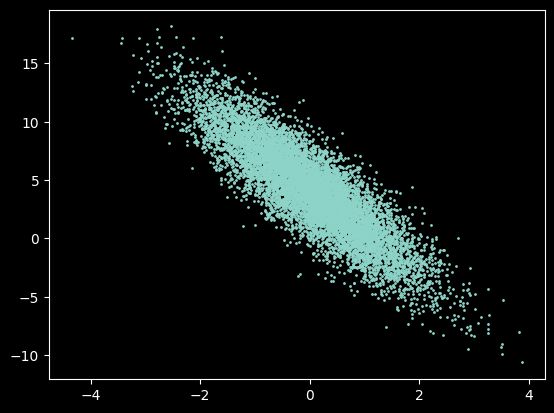

In [5]:
def synthetic_data(w, b, num_examples): #@save
    """生成y=Xw+b噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1)) # 将标签换成n行1列的形状

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 10000)
print('features:', features[0],'\nlabel:', labels[0])

# .detach: 画图不需要张量追踪梯度，切断计算图
# .numpy()：tensor不能直接被matplotlib识别，需转成numpy
plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

##### 3.2.2 读取数据集
定义一个data_iter函数，用于批量大小、特征矩阵和标签向量作为输入，生成大小为batch_size的小批量，每个小批量包含一组特征和标签。

In [30]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)        # 总样本数
    indices = list(range(num_examples)) # 生成[0,1,2,...,999]索引
    random.shuffle(indices)             # 打乱顺序
    for i in range(0, num_examples, batch_size):
        # 取一小段索引
        batch_indices = torch.tensor(indices[i: min(i+batch_size, num_examples)])
        # 每次返回一小批数据，不结束函数（迭代器）
        yield features[batch_indices], labels[batch_indices]

batch_size = 10
# 看一下第一批的数据
for X,  y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[-1.4127,  0.5646],
        [-0.2805, -0.5378],
        [ 1.3741,  1.7343],
        [ 0.6168,  0.5689],
        [ 0.0532,  0.3080],
        [ 1.4540, -1.1689],
        [ 0.2158, -0.5324],
        [-0.2075, -0.0108],
        [ 1.3756,  0.2708],
        [-0.9568, -0.8546]]) 
 tensor([[-0.5479],
        [ 5.4635],
        [ 1.0433],
        [ 3.5026],
        [ 3.2601],
        [11.0988],
        [ 6.4299],
        [ 3.8156],
        [ 6.0256],
        [ 5.1836]])


##### 3.2.3 初始化模型参数
通过从均值为0，标准差为0.01的正让i分布中抽样随机数来初始化权重，偏置初始化为0。

In [31]:
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

##### 3.2.4 定义模型
定义模型，将模型的输入和参数同模型的输出关联起来。
- 广播机制：向量+标量会令标量加到向量的每一个分量上。

In [32]:
def linreg(X, w, b): #@save
    """线性回归模型"""
    return torch.matmul(X, w) + b

##### 3.2.5 定义损失函数
```y.reshape(y_hat.shape)```：确保真实值y的形状与预测值y_hat一致，以实现：
$$L(\mathbf{w},b)=\frac{1}{2n}\sum^n_{i=1}(\hat{y}^{(i)}-y^{(i)})^2$$

In [46]:
def squared_loss(y_hat, y): #@save
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

##### 3.2.6 定义优化算法
实现小批量随机梯度下降更新，接收模型参数几何、学习率和批量大小作为输入。
- params：模型参数列表
- lr：学习率，决定每一步的更新的大小

In [49]:
def sgd(params, lr, batch_size):    #@save
    """小批量随机梯度下降"""
    with torch.no_grad():       # 禁用梯度跟踪，不构建计算图
        for param in params:
            param -= lr * param.grad / batch_size   # 更新参数
            param.grad.zero_()   # 清零梯度

##### 3.2.7 训练
执行以下迭代：
- 初始化参数
  - 计算梯度$$\mathbf{b}\leftarrow\partial_{(\mathbf{w},b)}\frac{1}{|B|}\sum_{i\in B}l(\mathbf{x}^{(i)},y^{(i)},\mathbf{b},b)$$
  - 更新参数$$(\mathbf{w},b)\leftarrow(\mathbf{w},b)-\eta\mathbf{g}$$
- num_epochs，lr均为超参数，分别设为3和0.03。

In [58]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)       # X和y的小批量损失
        l.sum().backward()
        sgd([w, b], lr, batch_size)     # 使用参数的梯度更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

print(f'w的估计误差：{true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差：{true_b - b}')

epoch 1, loss 0.000050
epoch 2, loss 0.000051
epoch 3, loss 0.000051
w的估计误差：tensor([-0.0005,  0.0004], grad_fn=<SubBackward0>)
b的估计误差：tensor([-0.0005], grad_fn=<RsubBackward1>)


#### 3.3 线性回归的简洁实现
- 线性回归的简洁实现：使用框架内置的线性回归模型、损失函数和优化算法。
##### 3.3.1 生成数据集

In [6]:
import numpy as np
import torch
from torch.utils import data

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

##### 3.3.2 读取数据集
- 使用框架内置的data.TensorDataset和data.DataLoader来读取数据。
- ```dataset = data.TensorDataset(*data_arrays)```：将特征和标签组合成一个数据集；
- ```is_train```：指示是否需要在每轮迭代中打乱数据，True表示训练集需要打乱，False表示训练集不打乱；
- ```data.TensorDataset(*data_arrays)```：将多个张量打包成一个数据集，*表示解包（拆开元组）。
- ```next(iter(data_iter))```：获取data_iter迭代器的下一个元素，即一个小批量的特征和标签。```data_iter```可迭代对象，每次迭代返回一个小批量的```(features, labels)```，```iter```是将```data_iter```转换为迭代器对象，```next```则获取迭代器的下一个元素。

In [8]:
def load_array(data_arrays, batch_size, is_train=True): #@save
    """构造一个PyTorch数据迭代器"""
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

batch_size = 10
data_iter = load_array((features, labels), batch_size)
next(iter(data_iter))

[tensor([[ 0.5886, -0.3603],
         [-1.3390,  1.7635],
         [-0.3535, -0.8489],
         [-0.7276,  0.0100],
         [ 0.1556,  0.2023],
         [ 1.8166, -0.8038],
         [ 1.0357,  1.3869],
         [-1.1516,  0.9982],
         [ 0.8767, -1.4866],
         [ 1.5024,  0.7071]]),
 tensor([[ 6.6030],
         [-4.4808],
         [ 6.3897],
         [ 2.7232],
         [ 3.8164],
         [10.5692],
         [ 1.5506],
         [-1.4959],
         [11.0058],
         [ 4.7743]])]

##### 3.3.3 定义模型
- 使用框架内置的nn模块来定义模型。
定义一个模型变量```net```，作为一个```Sequential```类实例。```Sequential```类是一个容器，包含了多个层（Layer），这些层会按照它们被添加的顺序依次执行。```nn.Linear```是一个全连接层，接受输入特征的数量和输出特征的数量作为参数。在这个例子中，输入特征的数量是2（对应于房屋的面积和房龄），输出特征的数量是1（对应于房价）。因此，```nn.Linear(2, 1)```表示一个从2维输入到1维输出的线性层。
- 神经网路（Neural Network, nn）

In [10]:
from torch import nn
net = nn.Sequential(nn.Linear(2, 1))

##### 3.3.4 初始化模型参数
通过```net[0]```选择网络中的第一层，使用```weight.data```和```bias.data```访问参数。

In [11]:
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)

tensor([0.])

##### 3.3.5 定义损失函数
- 计算均方误差使用的是```MSELoss```类，默认返回所有样本损失的平均值。

In [14]:
loss = nn.MSELoss()

##### 3.3.6 定义优化算法
- **创建一个随机梯度下降（Stochastic Gradient Descent, SGD）优化器**，用于后续训练过程中自动更新模型参数（权重和偏置）。这个优化器会根据损失函数的梯度，自动调整参数，使模型拟合数据。
- ```torch.optim.SGD```：PyTorch中实现随机梯度下降的优化器类。它接受模型参数和学习率作为输入，并在训练过程中更新这些参数以最小化损失函数。
- ```net.parameters()```：返回模型中所有需要优化的参数（权重和偏置）。这些参数将被传递给优化器，以便在训练过程中进行更新。
- ```lr=0.03```：设置学习率（learning rate）为0.03。学习率是一个超参数，控制每次参数更新的步长大小。学习率越大，参数更新越快，但可能不稳定；越小，训练越慢但更稳定。
- ```trainer```：变量名，表示优化器实例，可以在训练过程中调用```trainer.step()```来更新模型参数。

In [13]:
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

##### 3.3.7 训练
- 在每一轮训练里，完整遍历一次数据集```train_data```，不断地从中获取一个小批量的输入和对应标签，对每个小批量执行以下步骤：
  - 通过调用```net(X)```生成预测并计算损失```l```（前向传播）；
  - 通过反向传播来计算梯度；
  - 通过调用优化器来更新模型参数。
- ```net(X)```：调用模型的前向传播方法，输入小批量特征X，输出预测值；
- ```loss(net(X), y)```：计算预测值与真实标签y之间的损失。

In [16]:
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X), y)     # 前向传播
        trainer.zero_grad()     # 梯度清零
        l.backward()            # 反向传播计算梯度
        trainer.step()          # 更新参数
    l = loss(net(features), labels)
    print(f'epoch {epoch + 1}, loss {l:f}')


epoch 1, loss 0.000095
epoch 2, loss 0.000094
epoch 3, loss 0.000095


##### “小批量总损失”与“小批量损失的平均值”的区别
- 小批量总损失：指的是一个batch内所有的样本损失的**总和**，如```l.sum()```；
- 小批量损失的平均值：指的是一个batch内所有的样本损失的**平均值**，如```l.mean()```。
在PyTorch中，默认情况下，损失函数（如```nn.MSELoss()```）返回的是小批量损失的平均值。
```python
loss = nn.MSELoss(reduction='sum')      # 总损失，即平方误差的和
loss = nn.MSELoss(reduction='mean')     # 平均损失，即平方误差的平均值
```